## neural network is basically a massive set of math expressions

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#%pip install graphviz

In [ ]:
def f(x): # a scalar valued function, takes a single scalar x and return a single scalar y
    return 3*x**2 - 4*x+5

In [ ]:
f(3.0)

In [ ]:
# create a set of scale values to feed in
xs = np.arange(-5, 5, 0.25)
# call f on xs to get a set of ys
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
# trying to find the derivative of this function at any single input point x
h = 0.0000001
x = 2/3
(f(x+h) - f(x))/h #(f(x+h) - f(x)): how much the function responded in the positive direction; /h: normalize by the run to get the slope

In [ ]:
# get a bit more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

In [ ]:
# now look at the derivatives of d with respect to a b and c
h = 0.0001

#inputs
a=2.0
b=-3.0
c=10.0


d1=a*b+c
# a += h
# b += h
c += h
d2=a*b+c
print('d1: ', d1)
print('d2: ', d2)
print('slope: ', (d2-d1)/h)

In [ ]:
# start building the "data structure" that maintain the math expressions
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self,other),'+')
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other),'*')
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        return out


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
d
f = Value(-2.0, label='f')
L = f*d; L.label='L'


In [ ]:
# a nicer way to visualize the expressions that are being built

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
draw_dot(L)

the output of the forward pass is -8, now we run back propagation(a recursive use of chain rule), starting with L calculate the derivative with respect to each node 
so we want to see how the change of each node have impact on L

In [ ]:
L = d*f
# dL/dd=? f (f(x+h)-f(x))/h

In [ ]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0

In [ ]:
draw_dot(L)

# Chain Rule
If a variable z depends on the variable y, which itself depends on the variable x (that is, y and z are dependent variables), then z depends on x as well, via the intermediate variable y. In this case, the chain rule is expressed as

dz/dx = dz/dy * dy/dx

dL / dc <- what's dd / dc (answer is 1.0)
dd / dc = 1.0 = dd / de
d = c+e

WANT:
dL / dc = (dL / dd) * (dd / dc)

KNOW:
dL / dd
dd / dc

==> c.grad = e.grad = d.grad = -2.0

In [ ]:
c.grad = e.grad = d.grad = -2.0
draw_dot(L)

dL / de = -2.0
e = a * b
de / da ?
dL / da = (dL / de) * (de / da)

In [ ]:
a.grad = -2.0*-3.0
b.grad= -2.0*2.0
draw_dot(L)

iterated through all nodes one by one, locally apply the chain rule

In [ ]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b
d=e+c
L=d*f

print(L.data)

In [ ]:
def lol(): # verification function
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = f*d; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0 , label='f')
    L = f*d; L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

Another example of manual backpropagation: backpropagate a neuron

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

# here is the neuron model being used below :

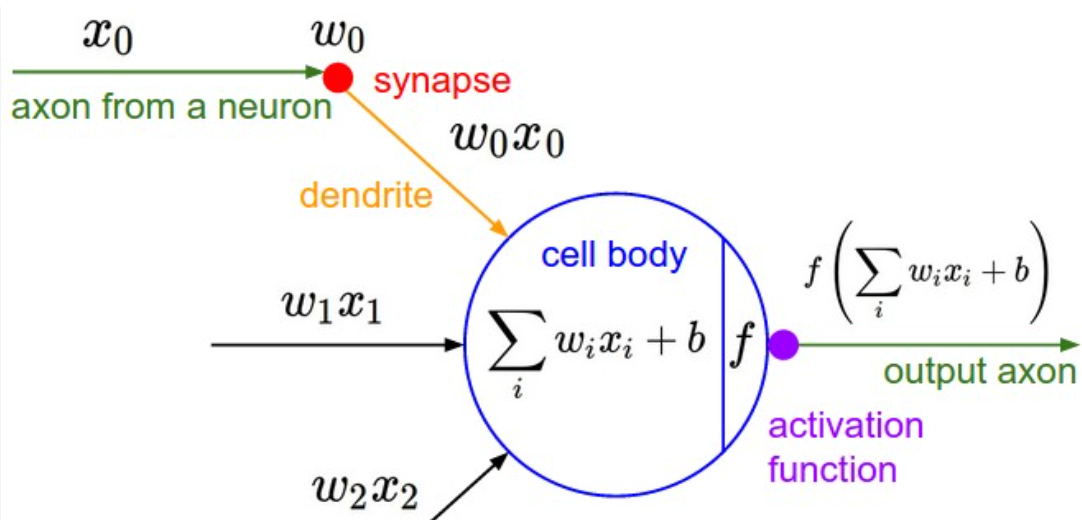

In [ ]:
# inputs x1,x2 create a 2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # the n here is the cell body above(raw activation without the activation function)
#draw_dot(n)
o = n.tanh(); o.label = 'o'
draw_dot(o)

now start the backpropagation to fill up all the grads

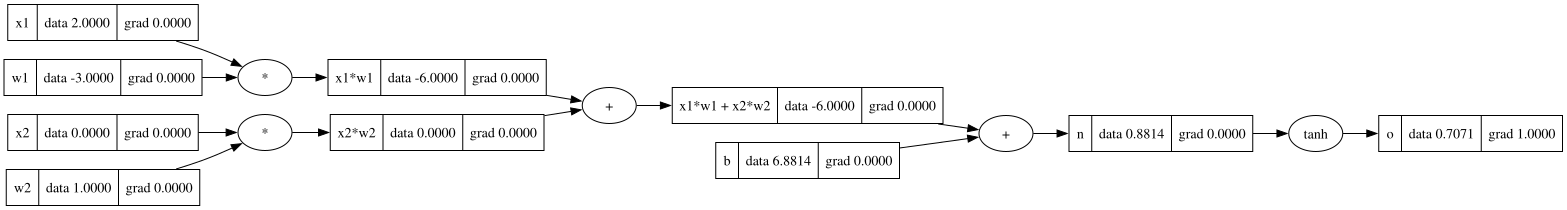

In [84]:
o.grad = 1.0
draw_dot(o)